# Fast-Delivery Network Design Under Demand Uncertainty

**Goal:** design a distribution network (which facilities to build/expand use, how much capacity to reserve)
that moves product from **known supply** points to **uncertain demand** points as *fast* and *cheaply*
as possible, while meeting a target service level.

This notebook walks through the full pipeline:

1. **Problem identification** — what makes this hard, and what "fast flow" means precisely
2. **ML layer** — probabilistic demand forecasting → scenario generation
3. **Optimization layer** — two-stage stochastic network flow (design + recourse)
4. **Alternative direction** — robust optimization (worst-case protection)
5. **Evaluation** — out-of-sample stress test of the chosen design
6. **Discussion of other directions** (chance constraints, RL, decision-focused learning)

> This is a self-contained, runnable dummy example meant as a *template* —
> swap in your simulated data and assumptions for a larger network.


## 1. Problem Identification

### Setting
- **Supply**: known and fixed. `S` origin nodes (e.g., plants / DCs) each with a known capacity.
- **Demand**: uncertain. `D` destination nodes (e.g., regional markets) with demand that varies
  day to day, known only as a *distribution*, not a fixed number.
- **Network**: a set of candidate lanes (origin → destination), each with a cost per unit,
  a transit time, and (optionally) a capacity.
- **"Fast flow"**: flow must arrive within a target lead time; unmet or late demand is penalized.

### What makes this genuinely hard
| Challenge | Why it matters |
|---|---|
| Demand is a *distribution*, not a number | A network sized for the mean demand will under-serve on high-demand days and waste capacity on low-demand days |
| Design decisions are made **before** demand is known | Which lanes to open / how much capacity to reserve must be decided "here-and-now"; routing can adapt "after the fact" (recourse) |
| Two conflicting objectives | Cost minimization vs. service-level / speed maximization — need an explicit trade-off, not two separate models |
| Combinatorics | Lane selection is often binary (open/close), demand allocation is continuous → mixed-integer program |
| Correlated demand across nodes/time | Independent per-node forecasts understate network-wide risk (e.g., all regions spike together in a promo) |

### Reformulated objective
> Choose **first-stage** network design decisions (open lanes, reserve capacity) to **minimize
> expected total cost** (transportation + lateness/unmet-demand penalty), **subject to a
> service-level constraint**, where **second-stage** flow/routing decisions adapt to each
> realized demand scenario.

This is exactly the structure of a **two-stage stochastic program with recourse**.


## 2. Setup: Imports and Synthetic Network

We build a small network:
- 3 supply nodes (known capacity)
- 5 demand nodes (uncertain demand, historical data simulated with trend + seasonality + noise)
- Candidate lanes between every supply–demand pair, each with unit cost and transit time


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

import pulp

np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 4)

In [2]:
# --- Network topology ---
supply_nodes = ['S1', 'S2', 'S3']
demand_nodes = ['D1', 'D2', 'D3', 'D4', 'D5']

# Known supply capacity (units/day) at each origin
supply_capacity = {'S1': 400, 'S2': 350, 'S3': 300}

# Candidate lane cost ($/unit) and transit time (days) -- fabricated but structured
np.random.seed(0)
lane_cost = {}
lane_time = {}
for s in supply_nodes:
    for d in demand_nodes:
        lane_cost[(s, d)] = round(np.random.uniform(2, 10), 2)
        lane_time[(s, d)] = np.random.choice([1, 2, 3], p=[0.5, 0.3, 0.2])

FAST_THRESHOLD_DAYS = 2  # lanes with transit_time > this are 'slow' -> extra penalty
LATE_PENALTY = 15        # $/unit penalty for routing via a slow lane
UNMET_PENALTY = 40       # $/unit penalty for demand that cannot be served at all

pd.DataFrame({
    'lane_cost': lane_cost,
    'lane_time': lane_time
}).reset_index().rename(columns={'level_0': 'supply', 'level_1': 'demand'}).head(10)


,supply,demand,lane_cost,lane_time
0,S1,D1,6.39,2
1,S1,D2,6.82,2
2,S1,D3,5.39,2
3,S1,D4,5.50,3
4,S1,D5,9.71,1
5,S2,D1,8.33,2
6,S2,D2,6.54,3
7,S2,D3,2.57,1
8,S2,D4,2.16,3
9,S2,D5,8.23,3


In [3]:
# --- Historical demand data (synthetic): trend + weekly seasonality + noise, per demand node ---
n_days = 260  # ~1 trading year
dates = pd.date_range('2024-01-01', periods=n_days, freq='D')

base_level = {'D1': 120, 'D2': 90, 'D3': 150, 'D4': 70, 'D5': 110}
trend_slope = {'D1': 0.05, 'D2': 0.02, 'D3': -0.03, 'D4': 0.01, 'D5': 0.04}
noise_scale = {'D1': 18, 'D2': 12, 'D3': 22, 'D4': 10, 'D5': 16}

records = []
for i, dt in enumerate(dates):
    dow = dt.dayofweek
    weekly = 1.0 + (0.25 if dow in [4, 5] else 0.0)  # Fri/Sat bump
    for d in demand_nodes:
        mean = (base_level[d] + trend_slope[d] * i) * weekly
        demand = max(0, np.random.normal(mean, noise_scale[d]))
        records.append({'date': dt, 'node': d, 'day_idx': i, 'dow': dow, 'demand': demand})

hist = pd.DataFrame(records)
hist.head()


,date,node,day_idx,dow,demand
0,2024-01-01,D1,0,0,135.559852
1,2024-01-01,D2,0,0,81.094020
2,2024-01-01,D3,0,0,199.934602
3,2024-01-01,D4,0,0,55.456343
4,2024-01-01,D5,0,0,110.732136


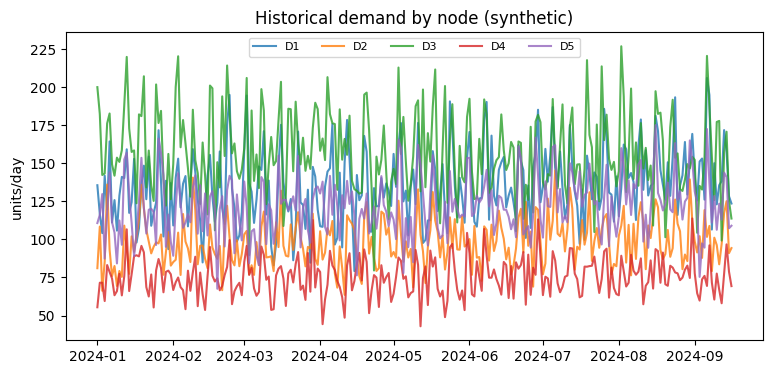

In [4]:
fig, ax = plt.subplots()
for d in demand_nodes:
    sub = hist[hist.node == d]
    ax.plot(sub['date'], sub['demand'], label=d, alpha=0.8)
ax.set_title('Historical demand by node (synthetic)')
ax.set_ylabel('units/day')
ax.legend(ncol=5, fontsize=8)
plt.show()


## 3. ML Layer: Probabilistic Demand Forecasting

Instead of a single point forecast, we need a **distribution** (or at least several quantiles)
of tomorrow's demand per node, because the optimizer needs to reason about *how much demand can
vary*, not just its average.

**Model choice**: gradient-boosted **quantile regression** (predicts P10 / P50 / P90 directly by
training three models with the pinball loss). This is a good default because it:
- requires no distributional assumption,
- captures nonlinear trend/seasonality effects,
- is easy to swap for DeepAR / N-BEATS / a Gaussian Process if you need cross-node correlation
  or a longer forecast horizon.

For a network with strong cross-node correlation (e.g., regional promos), a **multivariate /
hierarchical** forecaster would be a better next step — noted in the discussion at the end.


In [5]:
quantiles = [0.1, 0.5, 0.9]
features = ['day_idx', 'dow']

forecasts = {}  # node -> {quantile: predicted value for next day}

next_day_idx = n_days
next_dow = dates[-1].dayofweek  # placeholder; in practice use the actual next calendar day

for d in demand_nodes:
    sub = hist[hist.node == d]
    X = sub[features].values
    y = sub['demand'].values
    q_preds = {}
    for q in quantiles:
        model = GradientBoostingRegressor(loss='quantile', alpha=q,
                                           n_estimators=200, max_depth=2,
                                           learning_rate=0.05, random_state=0)
        model.fit(X, y)
        X_next = np.array([[next_day_idx, next_dow]])
        q_preds[q] = max(0, model.predict(X_next)[0])
    forecasts[d] = q_preds

pd.DataFrame(forecasts).T.rename(columns={0.1: 'P10', 0.5: 'P50', 0.9: 'P90'})


,P10,P50,P90
D1,123.404812,124.220653,158.515944
D2,80.496791,94.274741,108.152780
D3,113.688057,119.537378,175.366299
D4,59.861963,70.116814,82.986758
D5,107.537554,108.867024,128.423835


### Scenario generation

The optimizer needs discrete demand **scenarios**, not quantiles. We approximate each node's
demand distribution as (roughly) log-normal, calibrated to match the fitted P10/P50/P90, then
**sample jointly** across nodes with a modest positive correlation (network-wide demand tends to
move together — promos, holidays, macro effects).


In [6]:
from scipy.stats import norm

def lognormal_params_from_quantiles(p10, p50, p90):
    p50 = max(p50, 1e-3)
    mu = np.log(p50)
    z90 = norm.ppf(0.9)
    sigma = (np.log(max(p90, p50 + 1e-3)) - mu) / z90
    sigma = max(sigma, 1e-3)
    return mu, sigma

params = {d: lognormal_params_from_quantiles(forecasts[d][0.1], forecasts[d][0.5], forecasts[d][0.9])
          for d in demand_nodes}

N_SCENARIOS = 200
rho = 0.3  # cross-node demand correlation (shared shock)
n_d = len(demand_nodes)
cov = np.full((n_d, n_d), rho) + np.eye(n_d) * (1 - rho)

np.random.seed(1)
z = np.random.multivariate_normal(mean=np.zeros(n_d), cov=cov, size=N_SCENARIOS)

scenario_demand = np.zeros((N_SCENARIOS, n_d))
for j, d in enumerate(demand_nodes):
    mu, sigma = params[d]
    scenario_demand[:, j] = np.exp(mu + sigma * z[:, j])

scenarios_df = pd.DataFrame(scenario_demand, columns=demand_nodes)
scenarios_df.describe().loc[['mean', 'std', 'min', 'max']]


,D1,D2,D3,D4,D5
mean,125.939544,95.458475,121.382845,70.494554,110.384818
std,22.393118,10.864150,36.585081,9.136035,13.461427
min,76.261910,69.519235,55.481764,46.303833,73.678550
max,204.936711,126.435048,285.420363,96.245053,151.845691


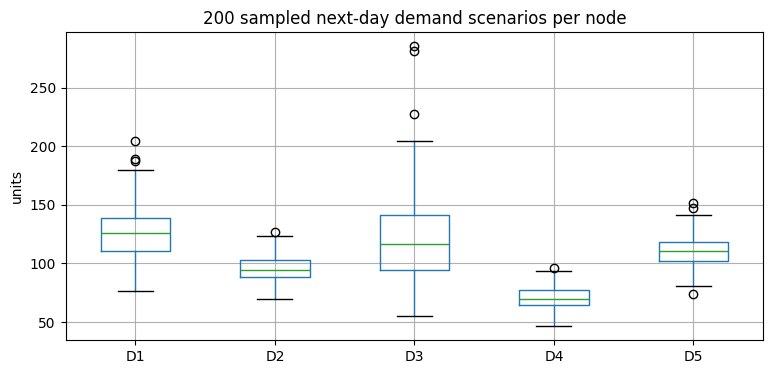

In [7]:
fig, ax = plt.subplots()
scenarios_df.boxplot(ax=ax)
ax.set_title(f'{N_SCENARIOS} sampled next-day demand scenarios per node')
ax.set_ylabel('units')
plt.show()


## 4. Optimization Layer: Two-Stage Stochastic Network Flow

**Stage 1 (here-and-now, before demand is known):**
- $x_{sd} \in \{0,1\}$: whether lane $(s,d)$ is *opened* (incurs a fixed setup cost — represents
  infrastructure/contract commitment for that lane)
- $c_{sd} \ge 0$: capacity reserved on lane $(s,d)$ if opened

**Stage 2 (recourse, after demand scenario $\omega$ is realized):**
- $f_{sd}^{\omega} \ge 0$: actual flow shipped on lane $(s,d)$ in scenario $\omega$ (bounded by
  reserved capacity and by supply)
- $u_d^{\omega} \ge 0$: unmet demand at node $d$ in scenario $\omega$ (penalized)

**Objective:** minimize fixed lane setup cost + expected (variable transport cost + late-lane
penalty + unmet-demand penalty) across scenarios, using **Sample Average Approximation (SAA)**:
average over the $N$ sampled scenarios in place of the true expectation.

**Service-level constraint:** average fill rate across scenarios must be $\ge$ target (e.g. 95%).

This is solved as a single large MILP (SAA turns the stochastic program into a deterministic
equivalent). For much larger scenario counts, Benders decomposition would separate stage 1 from
the (parallelizable) per-scenario stage-2 subproblems.


In [8]:
FIXED_LANE_COST = 150     # $ to open/commit a lane (amortized)
MAX_LANE_CAPACITY = 250   # cap on reservable capacity per lane
SERVICE_LEVEL_TARGET = 0.95

# Use a subset of scenarios for tractable SAA solve
N_SAA = 40
saa_idx = np.random.choice(N_SCENARIOS, N_SAA, replace=False)
saa_demand = scenarios_df.iloc[saa_idx].reset_index(drop=True)

prob = pulp.LpProblem('fast_flow_network_design', pulp.LpMinimize)

# Stage 1 variables
x = {(s, d): pulp.LpVariable(f'open_{s}_{d}', cat='Binary')
     for s in supply_nodes for d in demand_nodes}
cap = {(s, d): pulp.LpVariable(f'cap_{s}_{d}', lowBound=0, upBound=MAX_LANE_CAPACITY)
       for s in supply_nodes for d in demand_nodes}

# Stage 2 variables (per scenario)
f = {(s, d, w): pulp.LpVariable(f'flow_{s}_{d}_{w}', lowBound=0)
     for s in supply_nodes for d in demand_nodes for w in range(N_SAA)}
unmet = {(d, w): pulp.LpVariable(f'unmet_{d}_{w}', lowBound=0)
         for d in demand_nodes for w in range(N_SAA)}

# Objective: fixed cost + expected variable cost (SAA average)
fixed_cost = pulp.lpSum(FIXED_LANE_COST * x[(s, d)] for s in supply_nodes for d in demand_nodes)

variable_cost = pulp.lpSum(
    (1.0 / N_SAA) * (
        lane_cost[(s, d)] * f[(s, d, w)]
        + (LATE_PENALTY if lane_time[(s, d)] > FAST_THRESHOLD_DAYS else 0) * f[(s, d, w)]
    )
    for s in supply_nodes for d in demand_nodes for w in range(N_SAA)
)

unmet_cost = pulp.lpSum((1.0 / N_SAA) * UNMET_PENALTY * unmet[(d, w)]
                         for d in demand_nodes for w in range(N_SAA))

prob += fixed_cost + variable_cost + unmet_cost

# Capacity only usable if lane is open
for s in supply_nodes:
    for d in demand_nodes:
        prob += cap[(s, d)] <= MAX_LANE_CAPACITY * x[(s, d)]

# Per-scenario constraints
for w in range(N_SAA):
    # Supply cap at each origin (known, fixed)
    for s in supply_nodes:
        prob += pulp.lpSum(f[(s, d, w)] for d in demand_nodes) <= supply_capacity[s]
    # Flow on a lane cannot exceed reserved capacity
    for s in supply_nodes:
        for d in demand_nodes:
            prob += f[(s, d, w)] <= cap[(s, d)]
    # Demand balance: flow in + unmet = demand realized in this scenario
    for d in demand_nodes:
        prob += pulp.lpSum(f[(s, d, w)] for s in supply_nodes) + unmet[(d, w)] == saa_demand.loc[w, d]

# Service level: average fill rate across all node-scenarios >= target
total_demand_saa = saa_demand.values.sum()
prob += pulp.lpSum(unmet[(d, w)] for d in demand_nodes for w in range(N_SAA)) \
        <= (1 - SERVICE_LEVEL_TARGET) * total_demand_saa

status = prob.solve(pulp.PULP_CBC_CMD(msg=0))
print('Solve status:', pulp.LpStatus[status])
print('Total expected cost: $%.2f' % pulp.value(prob.objective))


Solve status: Optimal
Total expected cost: $4221.90


In [9]:
opened_lanes = [(s, d) for s in supply_nodes for d in demand_nodes if x[(s, d)].value() > 0.5]
design_df = pd.DataFrame([
    {'supply': s, 'demand': d,
     'reserved_capacity': round(cap[(s, d)].value(), 1),
     'unit_cost': lane_cost[(s, d)],
     'transit_days': lane_time[(s, d)],
     'fast': lane_time[(s, d)] <= FAST_THRESHOLD_DAYS}
    for (s, d) in opened_lanes
]).sort_values(['demand', 'supply'])

print(f'{len(opened_lanes)} lanes opened out of {len(supply_nodes) * len(demand_nodes)} candidates')
design_df


5 lanes opened out of 15 candidates


,supply,demand,reserved_capacity,unit_cost,transit_days,fast
0,S1,D1,250.0,6.39,2,True
3,S3,D2,250.0,5.69,2,True
1,S2,D3,250.0,2.57,1,True
2,S2,D4,250.0,2.16,3,False
4,S3,D5,250.0,6.17,1,True


Mean fill rate across SAA scenarios: 100.0%


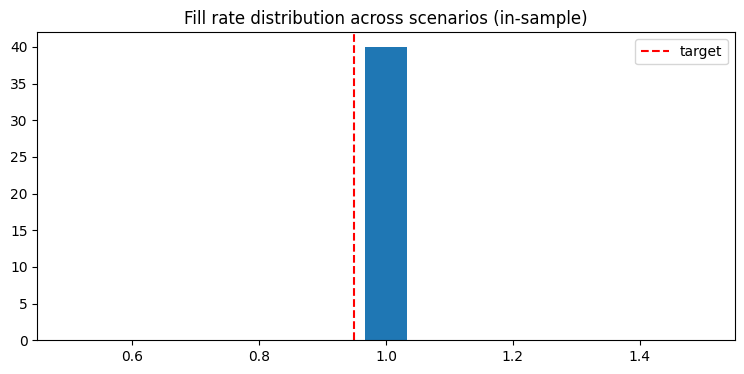

In [10]:
fill_rates = []
for w in range(N_SAA):
    total_d = saa_demand.loc[w].sum()
    total_u = sum(unmet[(d, w)].value() for d in demand_nodes)
    fill_rates.append(1 - total_u / total_d)

print('Mean fill rate across SAA scenarios: %.1f%%' % (100 * np.mean(fill_rates)))
plt.hist(fill_rates, bins=15)
plt.axvline(SERVICE_LEVEL_TARGET, color='red', linestyle='--', label='target')
plt.title('Fill rate distribution across scenarios (in-sample)')
plt.legend()
plt.show()


## 5. Out-of-Sample Validation

The design (which lanes are open, how much capacity is reserved) was optimized on `N_SAA=40`
sampled scenarios. Before trusting it, stress-test it against the **full 200-scenario set**
(including scenarios never seen during optimization) by re-solving *only* the recourse
(flow/unmet) problem for each new scenario, holding the design fixed.


Out-of-sample mean fill rate: 100.0%
Out-of-sample P10 fill rate:  100.0%


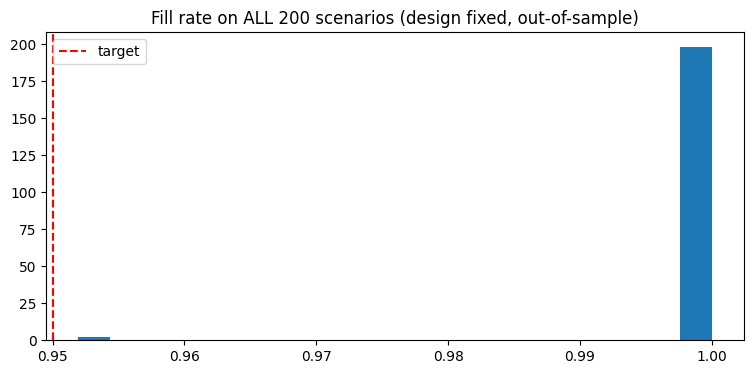

In [11]:
def evaluate_design_on_scenario(demand_vec):
    """Solve the stage-2 recourse LP for a single fixed design + one demand scenario."""
    sub = pulp.LpProblem('recourse', pulp.LpMinimize)
    f2 = {(s, d): pulp.LpVariable(f'f2_{s}_{d}', lowBound=0) for s in supply_nodes for d in demand_nodes}
    u2 = {d: pulp.LpVariable(f'u2_{d}', lowBound=0) for d in demand_nodes}

    sub += pulp.lpSum(lane_cost[(s, d)] * f2[(s, d)] for s in supply_nodes for d in demand_nodes) \
           + pulp.lpSum(UNMET_PENALTY * u2[d] for d in demand_nodes)

    for s in supply_nodes:
        sub += pulp.lpSum(f2[(s, d)] for d in demand_nodes) <= supply_capacity[s]
    for s in supply_nodes:
        for d in demand_nodes:
            sub += f2[(s, d)] <= cap[(s, d)].value()  # design fixed from stage-1 solve
    for d in demand_nodes:
        sub += pulp.lpSum(f2[(s, d)] for s in supply_nodes) + u2[d] == demand_vec[d]

    sub.solve(pulp.PULP_CBC_CMD(msg=0))
    total_d = sum(demand_vec.values())
    total_u = sum(u2[d].value() for d in demand_nodes)
    return 1 - total_u / total_d

oos_fill_rates = [evaluate_design_on_scenario(scenarios_df.iloc[w].to_dict())
                   for w in range(N_SCENARIOS)]

print('Out-of-sample mean fill rate: %.1f%%' % (100 * np.mean(oos_fill_rates)))
print('Out-of-sample P10 fill rate:  %.1f%%' % (100 * np.percentile(oos_fill_rates, 10)))

plt.hist(oos_fill_rates, bins=20)
plt.axvline(SERVICE_LEVEL_TARGET, color='red', linestyle='--', label='target')
plt.title('Fill rate on ALL 200 scenarios (design fixed, out-of-sample)')
plt.legend()
plt.show()


**Interpretation:** if the out-of-sample mean fill rate is close to (or above) the target and
the P10 tail isn't catastrophic, the design generalizes. If it degrades sharply, that's a signal
the SAA sample size (`N_SAA`) was too small, or that tail risk needs explicit protection —
which motivates the robust/chance-constrained variants below.
